#  Notebook 03 — Feature Engineering Flux Ct + Ht
**AVORUBY CASH** — Extraction de features climatiques et ressources

**Input :** `AVORUBY_Dataset_Ct_Final.csv` + `AVORUBY_Flux_Ht.csv`
**Output :** `processed/flux_Ct_Ht_features.csv` (60 features)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Chemins relatifs
BASE_PATH = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH = os.path.join(BASE_PATH, '..', 'AVR_DATA')
PROC_PATH = os.path.join(BASE_PATH, '..', 'processed')

print(' Librairies importées')
print('DATA_PATH:', DATA_PATH)
print(' PROC_PATH:', PROC_PATH)

 Librairies importées
DATA_PATH: C:\Users\ouakk\Desktop\AvoRuby_Temp\AvoRuby_Cash_Project\notebooks\..\AVR_DATA
 PROC_PATH: C:\Users\ouakk\Desktop\AvoRuby_Temp\AvoRuby_Cash_Project\notebooks\..\processed


## 1. Chargement des données

In [13]:
ct = pd.read_csv(os.path.join(DATA_PATH, 'AVORUBY_Dataset_Ct_Final.csv'))
ht = pd.read_csv(os.path.join(DATA_PATH, 'AVORUBY_Flux_Ht.csv'))

ct['Date'] = pd.to_datetime(ct['Date'])
ht['Date'] = pd.to_datetime(ht['Date'])

print(' Ct:', ct.shape)
print(' Ht:', ht.shape)
print(ct.head(3))

 Ct: (26298, 9)
 Ht: (1461, 3)
        Date   LAT  LON  ALLSKY_SFC_SW_DWN   RH2M  GWETTOP    T2M  \
0 2022-01-01  27.5 -7.5              15.63  38.58     0.30  13.56   
1 2022-01-01  27.5 -2.5              13.77  49.05     0.10  14.46   
2 2022-01-01  28.5 -7.5              15.16  32.34     0.22  14.80   

   Precipitations_mm    VPD  
0                0.0  0.954  
1                0.0  0.839  
2                0.0  1.139  


## 2. Agrégation spatiale Ct → une série temporelle quotidienne

In [14]:
ct_daily = ct.groupby('Date').agg(
    T2M=('T2M', 'mean'),
    RH2M=('RH2M', 'mean'),
    VPD=('VPD', 'mean'),
    Precipitations_mm=('Precipitations_mm', 'sum'),
    ALLSKY_SFC_SW_DWN=('ALLSKY_SFC_SW_DWN', 'mean'),
    GWETTOP=('GWETTOP', 'mean')
).reset_index()

print(' Ct agrégé:', ct_daily.shape)
print('Valeurs manquantes:\n', ct_daily.isnull().sum())

 Ct agrégé: (1461, 7)
Valeurs manquantes:
 Date                   0
T2M                    1
RH2M                   1
VPD                    1
Precipitations_mm      0
ALLSKY_SFC_SW_DWN      1
GWETTOP              366
dtype: int64


## 3. Traitement des valeurs manquantes

In [15]:
# GWETTOP a 25% de NaN → interpolation
ct_daily['GWETTOP'] = ct_daily['GWETTOP'].interpolate(method='linear').ffill().bfill()

for col in ['T2M', 'RH2M', 'VPD', 'ALLSKY_SFC_SW_DWN']:
    ct_daily[col] = ct_daily[col].interpolate(method='linear', limit=3).ffill().bfill()

print(' NaN après traitement:', ct_daily.isnull().sum().sum())

 NaN après traitement: 0


## 4. Features temporelles (encodage cyclique)

In [16]:
ct_daily['mois']       = ct_daily['Date'].dt.month
ct_daily['semaine']    = ct_daily['Date'].dt.isocalendar().week.astype(int)
ct_daily['jour_annee'] = ct_daily['Date'].dt.dayofyear
ct_daily['annee']      = ct_daily['Date'].dt.year

# Encodage cyclique — essentiel pour LSTM
ct_daily['sin_mois'] = np.sin(2 * np.pi * ct_daily['mois'] / 12)
ct_daily['cos_mois'] = np.cos(2 * np.pi * ct_daily['mois'] / 12)
ct_daily['sin_jour'] = np.sin(2 * np.pi * ct_daily['jour_annee'] / 365)
ct_daily['cos_jour'] = np.cos(2 * np.pi * ct_daily['jour_annee'] / 365)

print(' Features temporelles ajoutées')

 Features temporelles ajoutées


## 5. Features climatiques dérivées (Flux Ct)

In [17]:
# --- Moyennes mobiles ---
for window in [7, 14, 30]:
    ct_daily[f'T2M_ma{window}']   = ct_daily['T2M'].rolling(window, min_periods=1).mean()
    ct_daily[f'VPD_ma{window}']   = ct_daily['VPD'].rolling(window, min_periods=1).mean()
    ct_daily[f'Pluie_ma{window}'] = ct_daily['Precipitations_mm'].rolling(window, min_periods=1).sum()

# --- Écarts-types mobiles (volatilité) ---
for window in [7, 30]:
    ct_daily[f'T2M_std{window}'] = ct_daily['T2M'].rolling(window, min_periods=1).std().fillna(0)
    ct_daily[f'VPD_std{window}'] = ct_daily['VPD'].rolling(window, min_periods=1).std().fillna(0)

# --- Lags ---
for lag in [1, 3, 7, 14]:
    ct_daily[f'T2M_lag{lag}']   = ct_daily['T2M'].shift(lag)
    ct_daily[f'VPD_lag{lag}']   = ct_daily['VPD'].shift(lag)
    ct_daily[f'Pluie_lag{lag}'] = ct_daily['Precipitations_mm'].shift(lag)

# --- Indicateurs de stress ---
ct_daily['stress_thermique'] = (ct_daily['VPD'] > 2.5).astype(int)
ct_daily['t2m_anomalie']     = ct_daily['T2M'] - ct_daily['T2M_ma30']
ct_daily['vpd_anomalie']     = ct_daily['VPD'] - ct_daily['VPD_ma30']

# --- Évapotranspiration approchée ---
ct_daily['ETo_approx'] = (
    0.0023 * (ct_daily['T2M'] + 17.8)
    * (ct_daily['ALLSKY_SFC_SW_DWN'] ** 0.5) * 0.5
)

# --- Humidité sol normalisée ---
gwet_min, gwet_max = ct_daily['GWETTOP'].min(), ct_daily['GWETTOP'].max()
ct_daily['GWETTOP_norm'] = (ct_daily['GWETTOP'] - gwet_min) / (gwet_max - gwet_min + 1e-6)

print(' Features Ct:', ct_daily.shape[1], 'colonnes')

 Features Ct: 45 colonnes


## 6. Features ressources (Flux Ht)

In [18]:
# --- Moyennes mobiles NDWI ---
for window in [7, 14, 30]:
    ht[f'NDWI_ma{window}'] = ht['NDWI'].rolling(window, min_periods=1).mean()

# --- Lags ---
for lag in [1, 7, 14, 30]:
    ht[f'NDWI_lag{lag}']    = ht['NDWI'].shift(lag)
    ht[f'Surface_lag{lag}'] = ht['Surface'].shift(lag)

# --- Variations ---
ht['NDWI_delta7']    = ht['NDWI'].diff(7)
ht['Surface_delta7'] = ht['Surface'].diff(7)
ht['Surface_delta30']= ht['Surface'].diff(30)

# --- Normalisation + alerte ---
ht['Surface_norm']       = ht['Surface'] / ht['Surface'].max()
ht['alerte_secheresse']  = (ht['NDWI'] < -0.15).astype(int)

print(' Features Ht:', ht.shape[1], 'colonnes')

 Features Ht: 19 colonnes


## 7. Fusion finale + export

In [19]:
df = pd.merge(ct_daily, ht, on='Date', how='inner').dropna().sort_values('Date').reset_index(drop=True)

print(f' Dataset final: {df.shape}')
print(f' Période: {df.Date.min().date()} → {df.Date.max().date()}')
print(f' Nombre de features: {df.shape[1]-1}')

df.to_csv(os.path.join(PROC_PATH, 'flux_Ct_Ht_features.csv'), index=False)
print(' Fichier sauvegardé: processed/flux_Ct_Ht_features.csv')

 Dataset final: (1431, 63)
 Période: 2022-01-31 → 2025-12-31
 Nombre de features: 62
 Fichier sauvegardé: processed/flux_Ct_Ht_features.csv


## 8. Visualisations

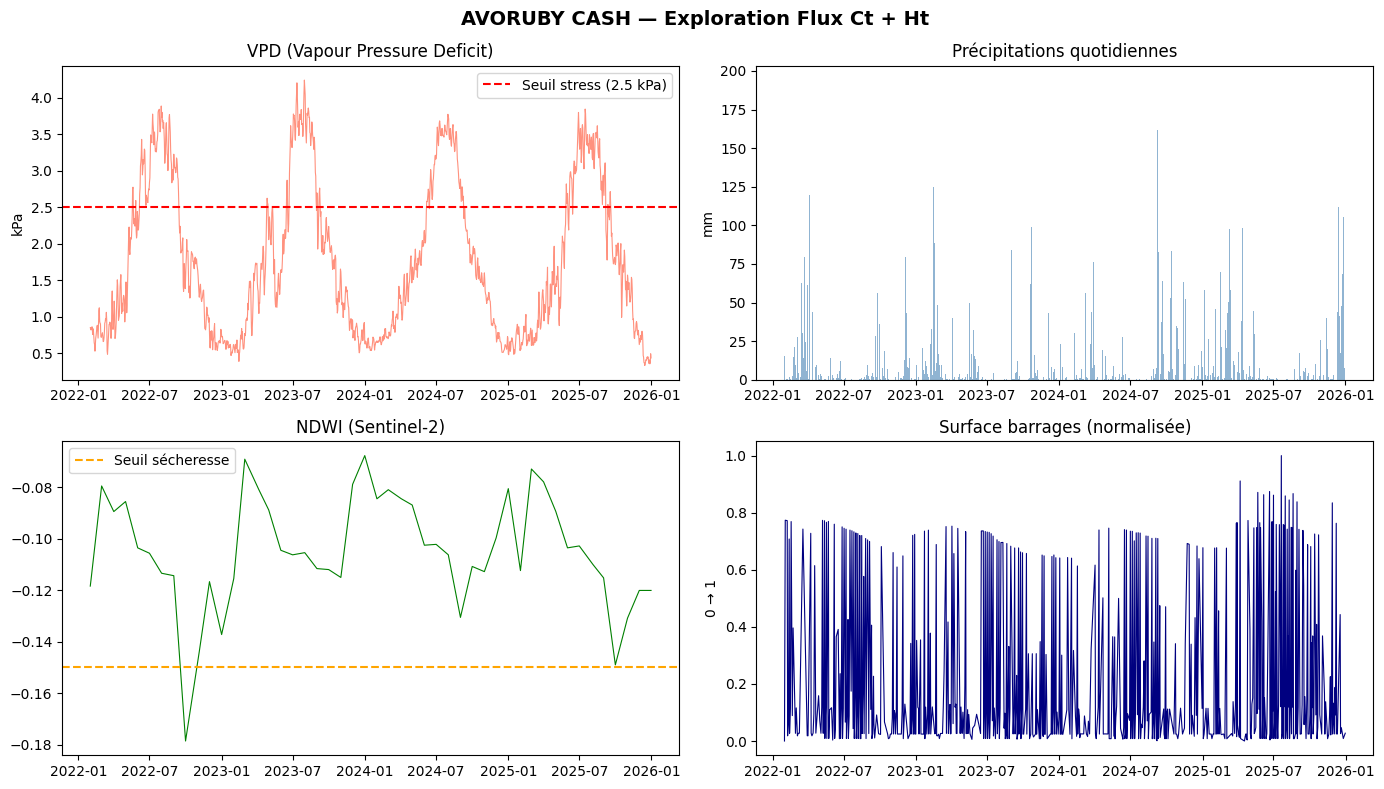

 Graphe sauvegardé


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('AVORUBY CASH — Exploration Flux Ct + Ht', fontsize=14, fontweight='bold')

# VPD dans le temps
axes[0,0].plot(df['Date'], df['VPD'], color='tomato', linewidth=0.8, alpha=0.7)
axes[0,0].axhline(2.5, color='red', linestyle='--', label='Seuil stress (2.5 kPa)')
axes[0,0].set_title('VPD (Vapour Pressure Deficit)')
axes[0,0].set_ylabel('kPa')
axes[0,0].legend()

# Précipitations
axes[0,1].bar(df['Date'], df['Precipitations_mm'], color='steelblue', alpha=0.6, width=1)
axes[0,1].set_title('Précipitations quotidiennes')
axes[0,1].set_ylabel('mm')

# NDWI
axes[1,0].plot(df['Date'], df['NDWI'], color='green', linewidth=0.8)
axes[1,0].axhline(-0.15, color='orange', linestyle='--', label='Seuil sécheresse')
axes[1,0].set_title('NDWI (Sentinel-2)')
axes[1,0].legend()

# Surface barrages
axes[1,1].plot(df['Date'], df['Surface_norm'], color='navy', linewidth=0.8)
axes[1,1].set_title('Surface barrages (normalisée)')
axes[1,1].set_ylabel('0 → 1')

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, 'visualisation_Ct_Ht.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Graphe sauvegardé')

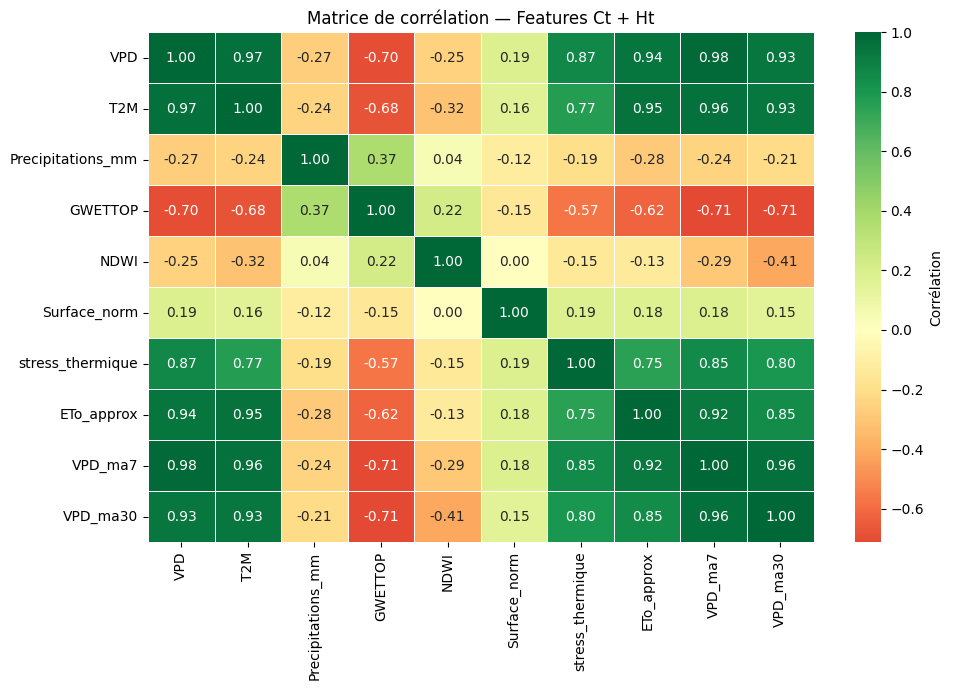

 Heatmap affichée


In [21]:
# Heatmap corrélations
features_key = ['VPD','T2M','Precipitations_mm','GWETTOP','NDWI','Surface_norm',
                'stress_thermique','ETo_approx','VPD_ma7','VPD_ma30']
corr = df[features_key].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de corrélation — Features Ct + Ht')
plt.tight_layout()
plt.show()
print(' Heatmap affichée')